# Phân loại bình luận độc hại tiếng Việt

## Thư viện

In [ ]:
# import thu vien
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pyvi import ViTokenizer

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent


## Tải dữ liệu

In [3]:
# doc du lieu
BASE_DIR = str(PROJECT_ROOT)
PROCESSED_DIR = f"{BASE_DIR}/data/processed"
MODEL_DIR = f"{BASE_DIR}/outputs/models"
METRIC_DIR = f"{BASE_DIR}/outputs/results"
FIGURE_DIR = f"{BASE_DIR}/outputs/figures"

train_df = pd.read_csv(f"{PROCESSED_DIR}/train_processed.csv")
dev_df = pd.read_csv(f"{PROCESSED_DIR}/val_processed.csv")
test_df = pd.read_csv(f"{PROCESSED_DIR}/test_processed.csv")

TEXT_COL = "text_clean"
LABEL_COL = "label_id"

train_df.shape, dev_df.shape, test_df.shape


((24046, 5), (2672, 5), (6680, 5))

In [4]:
# xem du lieu
train_df[[TEXT_COL, LABEL_COL]].head()

,text_clean,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯ...,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện ...,0


## Tách từ

In [5]:
# co dinh seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [6]:
# tach tu va tao tu dien
def segment_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text.strip().lower())
    return ViTokenizer.tokenize(text)

for df in [train_df, dev_df, test_df]:
    df["text_seg"] = df[TEXT_COL].fillna("").apply(segment_text)

def tokenize_text(text):
    return str(text).split()

def build_vocab(texts, min_freq=2, max_vocab=40000):
    counter = Counter()

    for text in texts:
        counter.update(tokenize_text(text))

    vocab = {"[PAD]": 0, "[UNK]": 1}

    for token, freq in counter.most_common():
        if freq < min_freq or len(vocab) >= max_vocab:
            break
        vocab[token] = len(vocab)

    return vocab

token_len = train_df["text_seg"].astype(str).str.split().str.len()
max_len = int(np.percentile(token_len, 98))
max_len = max(16, min(max_len, 64))

vocab = build_vocab(train_df["text_seg"], min_freq=2, max_vocab=40000)
vocab_size = len(vocab)

pd.DataFrame({
    "p95": [int(np.percentile(token_len, 95))],
    "p98": [int(np.percentile(token_len, 98))],
    "p99": [int(np.percentile(token_len, 99))],
    "max_len": [max_len],
    "vocab_size": [vocab_size]
})

,p95,p98,p99,max_len,vocab_size
0,32,47,59,47,8681


In [7]:
# tao dataset
def encode_text(text, vocab, max_len):
    tokens = tokenize_text(text)[:max_len]
    ids = [vocab.get(token, 1) for token in tokens]

    if len(ids) == 0:
        ids = [1]

    length = len(ids)

    if length < max_len:
        ids += [0] * (max_len - length)

    return ids, length

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, length = encode_text(self.texts[idx], self.vocab, self.max_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

train_dataset = TextDataset(train_df["text_seg"], train_df[LABEL_COL], vocab, max_len)
dev_dataset = TextDataset(dev_df["text_seg"], dev_df[LABEL_COL], vocab, max_len)
test_dataset = TextDataset(test_df["text_seg"], test_df[LABEL_COL], vocab, max_len)

label_count = train_df[LABEL_COL].value_counts().sort_index().to_dict()
sample_weights = train_df[LABEL_COL].map({k: 1.0 / v for k, v in label_count.items()}).values
train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

len(train_dataset), len(dev_dataset), len(test_dataset)

(24046, 2672, 6680)

## Mô hình BiLSTM

In [8]:
# mo hinh
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.emb_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 4, num_classes)

    def forward(self, input_ids, lengths):
        emb = self.emb_dropout(self.embedding(input_ids))

        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=input_ids.size(1)
        )

        mask = (input_ids != 0).unsqueeze(-1)
        output_masked = output.masked_fill(~mask, -1e9)
        max_pool = output_masked.max(dim=1).values

        sum_pool = (output * mask).sum(dim=1)
        valid_len = mask.sum(dim=1).clamp(min=1)
        mean_pool = sum_pool / valid_len

        feat = torch.cat([max_pool, mean_pool], dim=1)
        logits = self.fc(self.dropout(feat))
        return logits

def get_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    accuracy = accuracy_score(y_true, y_pred)

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    metrics = get_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / len(data_loader.dataset)

    return metrics, y_true, y_pred

In [9]:
# cau hinh train
EMBED_DIM = 300
HIDDEN_DIM = 128
NUM_CLASSES = 3
NUM_LAYERS = 2
DROPOUT = 0.4
LR = 8e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 12
PATIENCE = 3

model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

try:
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
except TypeError:
    criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

os.makedirs(MODEL_DIR, exist_ok=True)
BEST_MODEL_PATH = f"{MODEL_DIR}/bilstm_best.pt"

sum(p.numel() for p in model.parameters())

3441423

In [10]:
# train model
best_val_f1 = -1.0
best_epoch = 0
wait = 0
history_rows = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    train_loss = 0.0
    train_true = []
    train_pred = []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        train_true.extend(labels.cpu().numpy().tolist())
        train_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    train_metrics = get_metrics(train_true, train_pred)
    train_metrics["loss"] = train_loss / len(train_loader.dataset)

    dev_metrics, _, _ = evaluate_model(model, dev_loader, criterion, device)
    scheduler.step(dev_metrics["f1_macro"])

    history_rows.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1_macro": train_metrics["f1_macro"],
        "dev_loss": dev_metrics["loss"],
        "dev_accuracy": dev_metrics["accuracy"],
        "dev_f1_macro": dev_metrics["f1_macro"],
        "lr": optimizer.param_groups[0]["lr"]
    })

    print(
        f"epoch {epoch:02d} | "
        f"train_loss {train_metrics['loss']:.4f} | "
        f"dev_loss {dev_metrics['loss']:.4f} | "
        f"dev_f1 {dev_metrics['f1_macro']:.4f}"
    )

    if dev_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = dev_metrics["f1_macro"]
        best_epoch = epoch
        wait = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        wait += 1

    if wait >= PATIENCE:
        break

history_df = pd.DataFrame(history_rows)
history_df

epoch 01 | train_loss 0.8681 | dev_loss 0.7508 | dev_f1 0.5381
epoch 02 | train_loss 0.6401 | dev_loss 0.6960 | dev_f1 0.5725
epoch 03 | train_loss 0.5198 | dev_loss 0.6643 | dev_f1 0.5924
epoch 04 | train_loss 0.4465 | dev_loss 0.6748 | dev_f1 0.5947
epoch 05 | train_loss 0.4119 | dev_loss 0.6718 | dev_f1 0.6087
epoch 06 | train_loss 0.3736 | dev_loss 0.7082 | dev_f1 0.5935
epoch 07 | train_loss 0.3491 | dev_loss 0.6317 | dev_f1 0.6180
epoch 08 | train_loss 0.3353 | dev_loss 0.6497 | dev_f1 0.6157
epoch 09 | train_loss 0.3241 | dev_loss 0.6566 | dev_f1 0.6193
epoch 10 | train_loss 0.3067 | dev_loss 0.6528 | dev_f1 0.6222
epoch 11 | train_loss 0.2935 | dev_loss 0.6600 | dev_f1 0.6237
epoch 12 | train_loss 0.2880 | dev_loss 0.6588 | dev_f1 0.6184


,epoch,train_loss,train_accuracy,train_f1_macro,dev_loss,dev_accuracy,dev_f1_macro,lr
0,1,0.868119,0.618149,0.616742,0.750764,0.705838,0.538110,0.0008
1,2,0.640070,0.769442,0.769487,0.695999,0.757859,0.572519,0.0008
2,3,0.519755,0.836896,0.836769,0.664309,0.781437,0.592439,0.0008
3,4,0.446485,0.871413,0.870911,0.674822,0.787051,0.594744,0.0008
4,5,0.411911,0.890252,0.889916,0.671754,0.803144,0.608689,0.0008
5,6,0.373591,0.909257,0.909025,0.708200,0.779940,0.593453,0.0008
6,7,0.349076,0.921484,0.921343,0.631720,0.811377,0.618013,0.0008
7,8,0.335350,0.929094,0.928937,0.649749,0.807635,0.615665,0.0008
8,9,0.324056,0.933419,0.933391,0.656591,0.821108,0.619310,0.0008
9,10,0.306664,0.941238,0.941153,0.652809,0.812874,0.622188,0.0008


## Đánh giá

In [11]:
# test
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

test_metrics, y_test, test_pred = evaluate_model(model, test_loader, criterion, device)

metrics_df = pd.DataFrame([{
    "model": "BiLSTM",
    "best_epoch": best_epoch,
    "best_dev_f1": round(best_val_f1, 4),
    "accuracy": round(test_metrics["accuracy"], 4),
    "precision_macro": round(test_metrics["precision_macro"], 4),
    "recall_macro": round(test_metrics["recall_macro"], 4),
    "f1_macro": round(test_metrics["f1_macro"], 4),
    "vocab_size": vocab_size,
    "max_len": max_len,
    "batch_size": BATCH_SIZE,
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS
}])

metrics_df

,model,best_epoch,best_dev_f1,accuracy,precision_macro,recall_macro,f1_macro,vocab_size,max_len,batch_size,embed_dim,hidden_dim,num_layers
0,BiLSTM,11,0.6237,0.8293,0.5895,0.6512,0.615,8681,47,64,300,128,2


In [12]:
# bao cao chi tiet
report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_pred,
        labels=[0, 1, 2],
        target_names=["CLEAN", "OFFENSIVE", "HATE"],
        output_dict=True,
        zero_division=0
    )
).T

report_df.round(4)

,precision,recall,f1-score,support
CLEAN,0.9408,0.8848,0.9119,5548.0000
OFFENSIVE,0.3339,0.4279,0.3751,444.0000
HATE,0.4938,0.6410,0.5579,688.0000
accuracy,0.8293,0.8293,0.8293,0.8293
macro avg,0.5895,0.6512,0.6150,6680.0000
weighted avg,0.8544,0.8293,0.8398,6680.0000


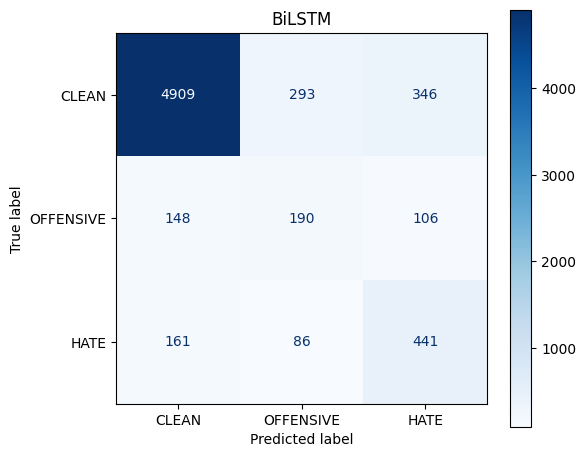

In [13]:
# ve confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["CLEAN", "OFFENSIVE", "HATE"],
    cmap="Blues",
    xticks_rotation=0,
    ax=ax
)

plt.title("BiLSTM")
plt.tight_layout()
plt.show()

## Lưu kết quả

In [14]:
# luu ket qua
os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(model.state_dict(), f"{MODEL_DIR}/bilstm_last.pt")

with open(f"{MODEL_DIR}/bilstm_vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)

history_df.to_csv(f"{METRIC_DIR}/bilstm_history.csv", index=False)
metrics_df.to_csv(f"{METRIC_DIR}/bilstm_metrics.csv", index=False)
report_df.to_csv(f"{METRIC_DIR}/bilstm_report.csv", index=True)

fig.savefig(f"{FIGURE_DIR}/bilstm_confusion_matrix.png", dpi=300, bbox_inches="tight")
